In [1]:
# =========================
# Cell 1 — Imports + config
# =========================
import os
import gzip
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Set

import pandas as pd

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Folder containing UCSD/McAuley review files (.json.gz)
DATA_DIR = "data/"  # <-- change this

# Pick 5 categories (update filenames as needed)
CATEGORY_FILES = {
    "Electronics": "Electronics_5.json.gz",
    "Clothing, Shoes and Jewelry": "Clothing_Shoes_and_Jewelry_5.json.gz",
    "Tools and Home Improvement": "Tools_and_Home_Improvement_5.json.gz",
    "Toys_and_Games": "Toys_and_Games_5.json.gz",
    "Sports_and_Outdoors": "Sports_and_Outdoors_5.json.gz",
}

# Sampling constraints
N_PRODUCTS_PER_CATEGORY = 10_000
MIN_REVIEWS_PER_PRODUCT = 20
MIN_HISTORY_DAYS = 28  # 4 weeks

# Output folder
OUT_DIR = Path("samples")
OUT_DIR.mkdir(exist_ok=True)

SECONDS_PER_DAY = 86400

In [2]:
# ==========================================
# Cell 2 — Streaming reader + ASIN statistics
# ==========================================
@dataclass
class AsinStats:
    count: int = 0
    min_time: int = 2**63 - 1
    max_time: int = 0

def iter_reviews_jsonl_gz(path: str) -> Iterable[dict]:
    """Yield review dicts from a .json.gz file (JSON Lines)."""
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)

def compute_asin_stats(path: str) -> Dict[str, AsinStats]:
    """1st pass: compute count/min/max unixReviewTime per ASIN."""
    stats: Dict[str, AsinStats] = {}
    for r in iter_reviews_jsonl_gz(path):
        asin = r.get("asin")
        t = r.get("unixReviewTime")
        if asin is None or t is None:
            continue
        s = stats.get(asin)
        if s is None:
            s = AsinStats()
            stats[asin] = s
        s.count += 1
        if t < s.min_time:
            s.min_time = t
        if t > s.max_time:
            s.max_time = t
    return stats

def eligible_asins(stats: Dict[str, AsinStats],
                   min_reviews: int,
                   min_history_days: int) -> List[str]:
    """Return ASINs meeting min review count and min history length."""
    min_span = min_history_days * SECONDS_PER_DAY
    return [
        asin for asin, s in stats.items()
        if s.count >= min_reviews and (s.max_time - s.min_time) >= min_span
    ]

def sample_asins(eligible: List[str], n: int) -> List[str]:
    """Sample n ASINs without replacement (or all if fewer than n)."""
    if len(eligible) <= n:
        return eligible
    return random.sample(eligible, n)

def load_reviews_for_asins(path: str, asins: Set[str]) -> pd.DataFrame:
    """2nd pass: load all reviews for selected ASINs into a DataFrame."""
    rows = []
    keep_keys = [
        "asin", "reviewerID", "overall", "reviewText", "summary",
        "unixReviewTime", "reviewTime", "verified", "vote", "style"
    ]
    for r in iter_reviews_jsonl_gz(path):
        asin = r.get("asin")
        if asin in asins:
            rows.append({k: r.get(k) for k in keep_keys})

    df = pd.DataFrame(rows)

    # Normalize common types
    if "unixReviewTime" in df.columns:
        df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
        df["review_dt"] = pd.to_datetime(df["unixReviewTime"], unit="s", errors="coerce", utc=True)
    if "overall" in df.columns:
        df["overall"] = pd.to_numeric(df["overall"], errors="coerce")

    return df

In [5]:
# ======================================================
# Cell 3 — Run sampling per category (two-pass per file)
# ======================================================
results = {}

for cat, fname in CATEGORY_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file for {cat}: {path}")

    print(f"\n=== Category: {cat} ===")
    print("Pass 1/2: computing per-ASIN stats...")
    stats = compute_asin_stats(path)
    print(f"Total unique ASINs seen: {len(stats):,}")

    elig = eligible_asins(stats, MIN_REVIEWS_PER_PRODUCT, MIN_HISTORY_DAYS)
    print(
        f"Eligible ASINs (>= {MIN_REVIEWS_PER_PRODUCT} reviews & "
        f">= {MIN_HISTORY_DAYS} days history): {len(elig):,}"
    )

    sampled = sample_asins(elig, N_PRODUCTS_PER_CATEGORY)
    print(f"Sampled ASINs: {len(sampled):,}")

    print("Pass 2/2: loading reviews for sampled ASINs into pandas...")
    df = load_reviews_for_asins(path, set(sampled))
    print(f"Loaded reviews: {len(df):,}")

    # Sanity checks at product level
    prod_counts = df.groupby("asin")["overall"].size()
    prod_span_days = (df.groupby("asin")["unixReviewTime"].max() -
                      df.groupby("asin")["unixReviewTime"].min()) / SECONDS_PER_DAY

    print(f"Products with >= {MIN_REVIEWS_PER_PRODUCT} reviews: {(prod_counts >= MIN_REVIEWS_PER_PRODUCT).sum():,} / {prod_counts.size:,}")
    print(f"Products with >= {MIN_HISTORY_DAYS} days span: {(prod_span_days >= MIN_HISTORY_DAYS).sum():,} / {prod_span_days.size:,}")

    # Save outputs
    cat_dir = OUT_DIR / cat
    cat_dir.mkdir(parents=True, exist_ok=True)

    asin_path = cat_dir / "sample_asins.csv"
    pd.Series(sampled, name="asin").to_csv(asin_path, index=False)

    parquet_path = cat_dir / "sample_reviews.parquet"
    df.to_parquet(parquet_path, index=False)

    results[cat] = {
        "asin_count": len(sampled),
        "review_rows": len(df),
        "asin_list_path": str(asin_path),
        "reviews_path": str(parquet_path),
    }

summary = pd.DataFrame(results).T
summary

,asin_count,review_rows,asin_list_path,reviews_path
Electronics,10000,996919,samples/Electronics/sample_asins.csv,samples/Electronics/sample_reviews.parquet
"Clothing, Shoes and Jewelry",10000,833344,"samples/Clothing, Shoes and Jewelry/sample_asi...","samples/Clothing, Shoes and Jewelry/sample_rev..."
Tools and Home Improvement,10000,693873,samples/Tools and Home Improvement/sample_asin...,samples/Tools and Home Improvement/sample_revi...
Toys_and_Games,10000,595796,samples/Toys_and_Games/sample_asins.csv,samples/Toys_and_Games/sample_reviews.parquet
Sports_and_Outdoors,10000,701443,samples/Sports_and_Outdoors/sample_asins.csv,samples/Sports_and_Outdoors/sample_reviews.par...


In [3]:
# ==========================================
# Cell 4 — Optional: combine into one dataset
# ==========================================
dfs = []
for cat in CATEGORY_FILES.keys():
    p = OUT_DIR / cat / "sample_reviews.parquet"
    d = pd.read_parquet(p)
    d["category"] = cat
    dfs.append(d)

all_reviews = pd.concat(dfs, ignore_index=True)
all_reviews.shape

(3821375, 12)

In [2]:
import pandas as pd
from pathlib import Path

SAMPLES_DIR = Path("samples")

ratings = []
review_counts = []

for category_dir in SAMPLES_DIR.iterdir():
    if not category_dir.is_dir():
        continue

    file_path = category_dir / "sample_reviews.parquet"

    # Load only columns we need
    df = pd.read_parquet(file_path, columns=["asin", "overall"])

    # Collect ratings
    ratings.append(df["overall"].dropna())

    # Compute review counts per product for this category
    counts = df.groupby("asin").size()
    review_counts.append(counts)

# Combine small Series (safe)
ratings = pd.concat(ratings)
review_counts = pd.concat(review_counts)

In [3]:
# Rating statistics
mean_rating = ratings.mean()
median_rating = ratings.median()
std_rating = ratings.std()

# Product-level review count statistics
mean_review_count = review_counts.mean()
median_review_count = review_counts.median()

print("Mean rating:", mean_rating)
print("Median rating:", median_rating)
print("Standard deviation of ratings:", std_rating)
print("Mean review count per product:", mean_review_count)
print("Median review count per product:", median_review_count)

Mean rating: 4.368376042654804
Median rating: 5.0
Standard deviation of ratings: 1.0946008237791667
Mean review count per product: 76.4275
Median review count per product: 39.0


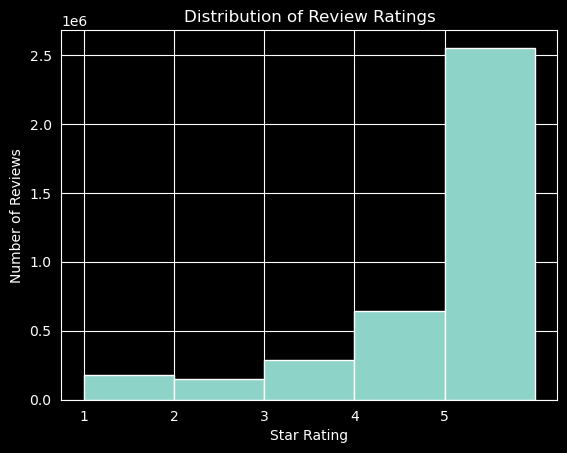

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(ratings, bins=[1,2,3,4,5,6])
plt.title("Distribution of Review Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks([1,2,3,4,5])
plt.show()

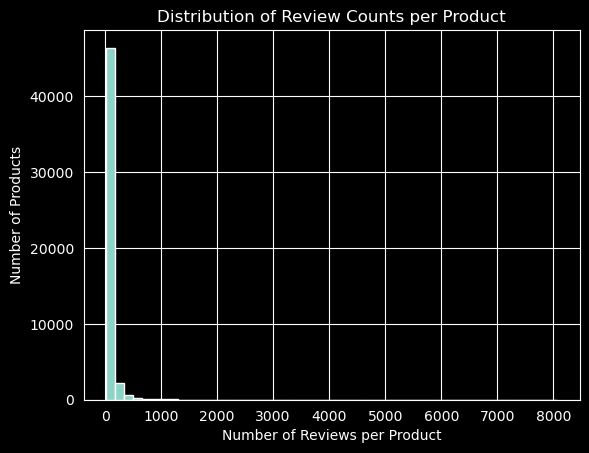

In [8]:
plt.figure()
plt.hist(review_counts, bins=50)
plt.title("Distribution of Review Counts per Product")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.show()

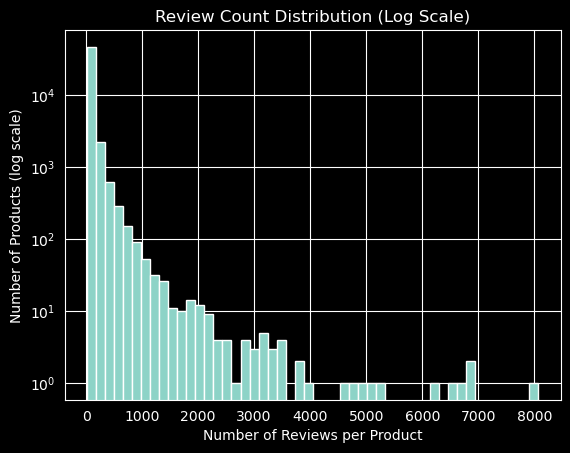

In [7]:
plt.figure()
plt.hist(review_counts, bins=50)
plt.yscale("log")
plt.title("Review Count Distribution (Log Scale)")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products (log scale)")
plt.show()

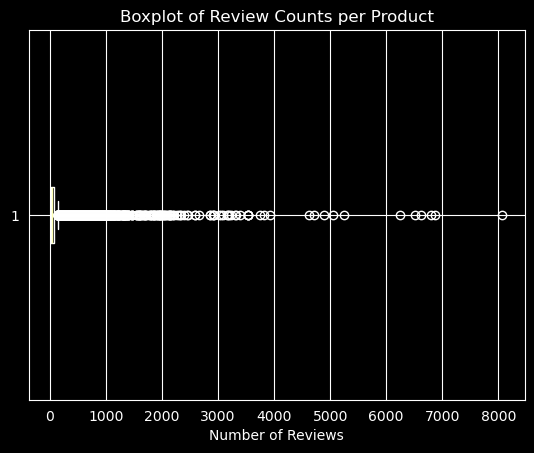

In [9]:
plt.figure()
plt.boxplot(review_counts, vert=False)
plt.title("Boxplot of Review Counts per Product")
plt.xlabel("Number of Reviews")
plt.show()

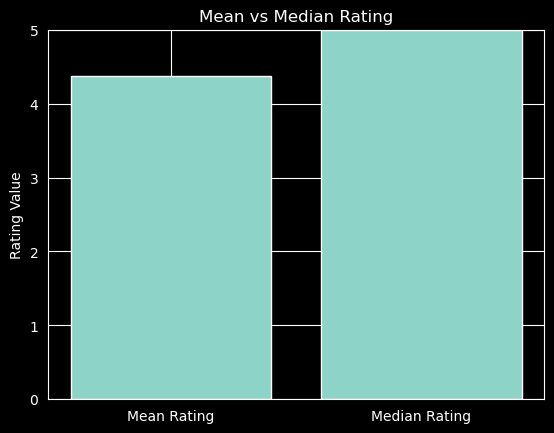

In [10]:
stats = [mean_rating, median_rating]
labels = ["Mean Rating", "Median Rating"]

plt.figure()
plt.bar(labels, stats)
plt.title("Mean vs Median Rating")
plt.ylabel("Rating Value")
plt.ylim(0,5)
plt.show()

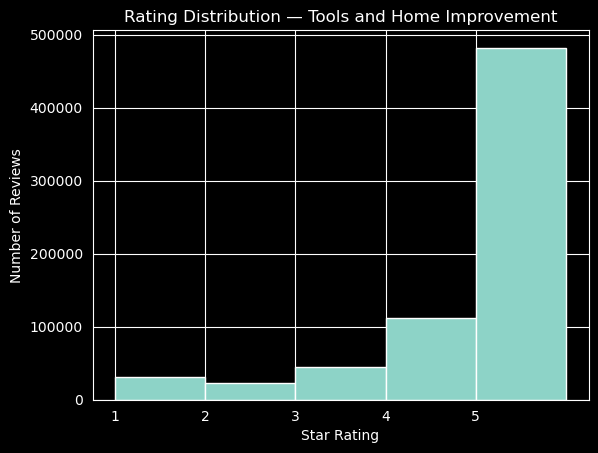

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

SAMPLES_DIR = Path("samples")

# Get list of category folders first
category_dirs = [d for d in SAMPLES_DIR.iterdir() if d.is_dir()]

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"

    df_cat = pd.read_parquet(file_path, columns=["overall"])

    fig, ax = plt.subplots()
    ax.hist(df_cat["overall"].dropna(), bins=[1,2,3,4,5,6])
    ax.set_title(f"Rating Distribution — {category_dir.name}")
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Number of Reviews")
    ax.set_xticks([1,2,3,4,5])

    plt.show()   # <-- ensures each plot renders
    plt.close(fig)  # <-- prevents memory buildup

In [ ]:
# ==========================================
# Cell 5A — Review-level EDA (summary + dists)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# Basic cleanup for EDA columns
df = all_reviews

# Helpful votes ("vote") is often a string like "1,234"
if "vote" in df.columns:
    df["vote_num"] = (
        df["vote"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("None", np.nan)
    )
    df["vote_num"] = pd.to_numeric(df["vote_num"], errors="coerce")
else:
    df["vote_num"] = np.nan

# Review length
df["review_text_clean"] = df["reviewText"].fillna("")
df["review_len_chars"] = df["review_text_clean"].str.len()
df["review_len_words"] = df["review_text_clean"].str.split().str.len()

# Review-level summary stats by category
review_level_summary = df.groupby("category").agg(
    n_reviews=("asin", "size"),
    n_products=("asin", "nunique"),
    rating_mean=("overall", "mean"),
    rating_median=("overall", "median"),
    rating_std=("overall", "std"),
    review_len_words_mean=("review_len_words", "mean"),
    review_len_words_median=("review_len_words", "median"),
    helpful_votes_mean=("vote_num", "mean"),
    verified_rate=("verified", lambda s: np.mean(s.fillna(False).astype(bool)) if "verified" in df.columns else np.nan),
).sort_values("n_reviews", ascending=False)

display(review_level_summary)

# Rating distribution (hist) per category
for cat in sorted(df["category"].unique()):
    sub = df[df["category"] == cat]
    plt.figure()
    plt.hist(sub["overall"].dropna(), bins=np.arange(0.5, 5.6, 1.0))
    plt.title(f"Rating distribution — {cat}")
    plt.xlabel("Star rating")
    plt.ylabel("Count")
    plt.show()

# Review length distribution (words)
for cat in sorted(df["category"].unique()):
    sub = df[df["category"] == cat]
    plt.figure()
    plt.hist(sub["review_len_words"].dropna(), bins=50)
    plt.title(f"Review length (words) distribution — {cat}")
    plt.xlabel("Words per review")
    plt.ylabel("Count")
    plt.xlim(0, np.nanpercentile(sub["review_len_words"], 99))  # reduce long tail in view
    plt.show()

# Helpful votes distribution (log-ish long tail)
plt.figure()
plt.hist(df["vote_num"].dropna().clip(upper=df["vote_num"].quantile(0.99)), bins=50)
plt.title("Helpful votes distribution (clipped at 99th pct)")
plt.xlabel("Helpful votes")
plt.ylabel("Count")
plt.show()

In [ ]:
# =========================================================
# Cell 5B — Product-level EDA (counts, rating stability, etc)
# =========================================================
# Build product-level stats
prod = df.groupby(["category", "asin"]).agg(
    n_reviews=("overall", "size"),
    first_time=("unixReviewTime", "min"),
    last_time=("unixReviewTime", "max"),
    rating_mean=("overall", "mean"),
    rating_std=("overall", "std"),
    verified_rate=("verified", lambda s: np.mean(s.fillna(False).astype(bool)) if "verified" in df.columns else np.nan),
    helpful_votes_mean=("vote_num", "mean"),
).reset_index()

prod["span_days"] = (prod["last_time"] - prod["first_time"]) / SECONDS_PER_DAY
prod["review_velocity_per_day"] = prod["n_reviews"] / prod["span_days"].replace(0, np.nan)

display(prod.groupby("category")[["n_reviews", "span_days", "review_velocity_per_day", "rating_mean", "rating_std"]].describe())

# Hist: reviews per product
for cat in sorted(prod["category"].unique()):
    sub = prod[prod["category"] == cat]
    plt.figure()
    plt.hist(sub["n_reviews"].clip(upper=sub["n_reviews"].quantile(0.99)), bins=60)
    plt.title(f"Reviews per product (clipped at 99th pct) — {cat}")
    plt.xlabel("# reviews per product")
    plt.ylabel("Count")
    plt.show()

# Boxplot: rating mean by category
cats = sorted(prod["category"].unique())
data = [prod.loc[prod["category"] == c, "rating_mean"].dropna().values for c in cats]
plt.figure()
plt.boxplot(data, labels=cats, showfliers=False)
plt.title("Product average rating by category (no outliers shown)")
plt.ylabel("Average rating")
plt.xticks(rotation=30, ha="right")
plt.show()

# Hist: review velocity per day
for cat in cats:
    sub = prod[prod["category"] == cat]
    plt.figure()
    plt.hist(sub["review_velocity_per_day"].dropna().clip(upper=sub["review_velocity_per_day"].quantile(0.99)), bins=60)
    plt.title(f"Review velocity per day (clipped at 99th pct) — {cat}")
    plt.xlabel("Reviews per day")
    plt.ylabel("Count")
    plt.show()

In [ ]:
# ==========================================================
# Cell 5C — Temporal features: early (first 4 weeks) vs later
# ==========================================================
# Define "launch" as first review timestamp for that product
df = df.merge(
    prod[["category", "asin", "first_time"]].rename(columns={"first_time": "launch_time"}),
    on=["category", "asin"],
    how="left",
)

df["days_since_launch"] = (df["unixReviewTime"] - df["launch_time"]) / SECONDS_PER_DAY

EARLY_DAYS = 28
LATE_DAYS = 180  # ~6 months horizon proxy for "long-term" (adjust as needed)

# Aggregate early vs long-term per product
early = df[df["days_since_launch"].between(0, EARLY_DAYS)].groupby(["category", "asin"]).agg(
    early_n_reviews=("overall", "size"),
    early_avg_rating=("overall", "mean"),
    early_rating_std=("overall", "std"),
    early_verified_rate=("verified", lambda s: np.mean(s.fillna(False).astype(bool)) if "verified" in df.columns else np.nan),
    early_avg_helpful=("vote_num", "mean"),
    early_avg_len_words=("review_len_words", "mean"),
).reset_index()

longterm = df[df["days_since_launch"].between(0, LATE_DAYS)].groupby(["category", "asin"]).agg(
    n_reviews_180d=("overall", "size"),
    avg_rating_180d=("overall", "mean"),
    rating_std_180d=("overall", "std"),
).reset_index()

panel = prod.merge(early, on=["category", "asin"], how="left").merge(longterm, on=["category", "asin"], how="left")

# Early velocity (per day) using early window
panel["early_velocity_per_day"] = panel["early_n_reviews"] / EARLY_DAYS

display(panel.head())

# Sanity: how many products have complete early window stats?
display(panel[["category", "asin", "early_n_reviews", "n_reviews_180d"]].isna().mean())

# Correlations (overall, not per-category yet)
corr_cols = [
    "early_n_reviews", "early_avg_rating", "early_velocity_per_day",
    "n_reviews_180d", "avg_rating_180d", "rating_std_180d"
]
corr = panel[corr_cols].corr(numeric_only=True)
display(corr)

In [ ]:
# ==========================================================
# Cell 5D — Core relationship plots + correlation heatmap
# ==========================================================
import matplotlib.pyplot as plt

# Scatter: early reviews vs reviews at 180d
plt.figure()
plt.scatter(panel["early_n_reviews"], panel["n_reviews_180d"], alpha=0.3)
plt.title("Early review count (first 4 weeks) vs total reviews (first 180 days)")
plt.xlabel("Reviews in first 28 days")
plt.ylabel("Reviews in first 180 days")
plt.xlim(0, panel["early_n_reviews"].quantile(0.99))
plt.ylim(0, panel["n_reviews_180d"].quantile(0.99))
plt.show()

# Scatter: early avg rating vs long-term review growth
plt.figure()
plt.scatter(panel["early_avg_rating"], panel["n_reviews_180d"], alpha=0.3)
plt.title("Early avg rating (first 4 weeks) vs total reviews (first 180 days)")
plt.xlabel("Early avg rating")
plt.ylabel("Reviews in first 180 days")
plt.ylim(0, panel["n_reviews_180d"].quantile(0.99))
plt.show()

# Scatter: early velocity vs long-term rating
plt.figure()
plt.scatter(panel["early_velocity_per_day"], panel["avg_rating_180d"], alpha=0.3)
plt.title("Early review velocity vs long-term avg rating (180 days)")
plt.xlabel("Early reviews/day (first 28 days)")
plt.ylabel("Avg rating in first 180 days")
plt.xlim(0, panel["early_velocity_per_day"].quantile(0.99))
plt.show()

# Heatmap: correlations
plt.figure()
plt.imshow(corr.values)
plt.title("Correlation heatmap (product-level features)")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Cell 5E — Temporal trajectories: cumulative reviews + rolling rating
# ==========================================================
# Pick a small set of example products per category for time-series plots
# (Avoid plotting thousands of lines; sample a few)
EXAMPLES_PER_CATEGORY = 5

example_asins = (
    prod.groupby("category", group_keys=False)
        .apply(lambda g: g.sample(min(EXAMPLES_PER_CATEGORY, len(g)), random_state=RANDOM_SEED))
        [["category", "asin"]]
)

example_pairs = list(map(tuple, example_asins.values))

# Prepare time series for examples
df_sorted = df.sort_values(["category", "asin", "review_dt"]).copy()

def plot_product_timeseries(cat: str, asin: str):
    sub = df_sorted[(df_sorted["category"] == cat) & (df_sorted["asin"] == asin)].copy()
    if sub.empty:
        return

    # Cumulative reviews
    sub["cum_reviews"] = range(1, len(sub) + 1)

    # Rolling avg rating (7-day window using time index)
    sub = sub.set_index("review_dt").sort_index()
    roll = sub["overall"].rolling("7D").mean()

    # Plot cumulative reviews
    plt.figure()
    plt.plot(sub.index, sub["cum_reviews"])
    plt.title(f"Cumulative reviews over time — {cat} / {asin}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative # reviews")
    plt.show()

    # Plot rolling rating
    plt.figure()
    plt.plot(roll.index, roll.values)
    plt.title(f"Rolling 7-day avg rating — {cat} / {asin}")
    plt.xlabel("Date")
    plt.ylabel("Rolling avg rating (7D)")
    plt.ylim(1, 5)
    plt.show()

for cat, asin in example_pairs:
    plot_product_timeseries(cat, asin)

In [ ]:
# ==========================================================
# Cell 5F — Simple "success" proxy + growth curves by success
# ==========================================================
# Define a preliminary success label (adjust later during modeling):
# Success = top 25% by reviews in first 180 days within each category
panel2 = panel.copy()
panel2["success_180d"] = (
    panel2.groupby("category")["n_reviews_180d"]
          .transform(lambda s: s >= s.quantile(0.75))
)

display(panel2.groupby("category")["success_180d"].mean())

# Plot average cumulative review curve for success vs non-success (sample to keep it quick)
# We'll compute daily counts relative to launch for a subset of products to keep runtime manageable.
MAX_PRODUCTS_PER_GROUP = 300  # adjust down if slow
MAX_DAYS = 180

# sample product lists per category/group
sampled_products = (
    panel2.groupby(["category", "success_180d"], group_keys=False)
          .apply(lambda g: g.sample(min(MAX_PRODUCTS_PER_GROUP, len(g)), random_state=RANDOM_SEED))
          [["category", "asin", "success_180d"]]
)

df_small = df.merge(sampled_products, on=["category", "asin"], how="inner")

# daily review counts relative to launch
df_small["day"] = df_small["days_since_launch"].floor().astype("int")
df_small = df_small[(df_small["day"] >= 0) & (df_small["day"] <= MAX_DAYS)]

daily = (
    df_small.groupby(["category", "success_180d", "asin", "day"])
            .size()
            .reset_index(name="n")
)

# cumulative per product, then average over products
daily["cum"] = daily.sort_values(["category", "success_180d", "asin", "day"]).groupby(
    ["category", "success_180d", "asin"]
)["n"].cumsum()

avg_curve = (
    daily.groupby(["category", "success_180d", "day"])["cum"]
         .mean()
         .reset_index()
)

# Plot curves
for cat in sorted(avg_curve["category"].unique()):
    sub = avg_curve[avg_curve["category"] == cat]
    plt.figure()
    for success_flag in [False, True]:
        ssub = sub[sub["success_180d"] == success_flag]
        plt.plot(ssub["day"], ssub["cum"], label=f"success={success_flag}")
    plt.title(f"Avg cumulative reviews (relative to launch) — {cat}")
    plt.xlabel("Days since launch (first review)")
    plt.ylabel("Avg cumulative # reviews")
    plt.legend()
    plt.show()